K Means Clustering - 2D

In [ ]:
import sys, os
# Adjust depth based on notebook location relative to project root
_src_path = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'src'))
if _src_path not in sys.path:
    sys.path.insert(0, _src_path)
from project_config import load_config

config    = load_config()
base_dir  = config['base_dir']
well_list = config['well_list']
well_meta = config.get('well_metadata', {})

print(f'Active experiment: {config.get("experiment_name", config.get("experiment_key", "?"))}')
print(f'Base dir: {base_dir}')

In [8]:
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import preprocessing
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import pandas as pd
import phate
import math
import random
import gc
import scprep
from datetime import datetime, time
from matplotlib.animation import ImageMagickWriter
import matplotlib.animation as animation
import zipfile
from urllib.request import urlopen
import scipy.stats as st
from scipy.stats import norm
from scipy.stats import gaussian_kde
from scipy.stats import kde
from scipy.stats import binned_statistic
from scipy.stats import f_oneway
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams['pdf.fonttype'] = 42
print(sns.__version__)
from anndata import AnnData
import scanpy as sc
from delve import *
import anndata as ad
from sklearn.preprocessing import MinMaxScaler
from kh import sketch
from sklearn.cluster import KMeans
import umap
print(sc.__version__)
today = datetime.now().strftime("%m%d%Y-%H%M")

0.11.2
1.9.1


In [9]:
#Read back in the subsampled adata file
adata_save_path = os.path.join(base_dir, 'standard_adata_sub__control_abema_PHATE.h5ad')
standard_adata_sub = anndata.read_h5ad(adata_save_path)

In [10]:
def laplacian_score_fs(adata = None,
                    k: int  = None,
                    n_jobs: int  = -1):

    X, feature_names, obs_names = parse_input(adata)
    W = construct_affinity(X = X, k = k, n_jobs = n_jobs)
    scores = laplacian_score(X = X, W = W)
    predicted_features = pd.DataFrame(scores, index = feature_names, columns = ['laplacian_score'])
    predicted_features = predicted_features.sort_values(by = 'laplacian_score', ascending = True)

    return predicted_features 

In [11]:
#l_score_fullest = laplacian_score_fs(adata_fullest_sub, k = 200)
l_score_standard = laplacian_score_fs(standard_adata_sub, k = 100)
#l_score_normalized = laplacian_score_fs(normalized_trimmed_noPSTAT5_adata_sub, k = 200)

In [12]:
len(l_score_standard)

38

In [13]:
l_score_standard.index[:38]

Index(['R2_cycB1_ring_mean', 'R0_CDK2_nuc_mean', 'R2_cycB1_nuc_mean',
       'R0_Rb_nuc_mean', 'R5_Cdt1_nuc_mean', 'R0_pRb_nuc_mean',
       'R3_p16_ring_mean', 'R0_CDK2_ring_mean', 'R3_cycA2_ring_mean',
       'R3_p16_nuc_mean', 'nuc_area', 'R4_pS6_nuc_mean', 'R3_Ki67_nuc_mean',
       'R1_CDK4_ring_mean', 'R5_E2F1_nuc_mean', 'R0_Rb_ring_mean',
       'R3_cycA2_nuc_mean', 'R4_S6_nuc_mean', 'R4_pS6_ring_mean',
       'R4_S6_ring_mean', 'R0_DNA_nuc_mean', 'R1_p21_nuc_mean',
       'R0_pRb_ring_mean', 'R2_cycD1_nuc_mean', 'R1_CDK4_nuc_mean',
       'R3_Ki67_ring_mean', 'R2_Mdm2_nuc_mean', 'minor_axis_length',
       'R5_E2F1_ring_mean', 'major_axis_length', 'orientation',
       'R1_p53_nuc_mean', 'R2_Mdm2_ring_mean', 'R1_p21_ring_mean',
       'R1_p53_ring_mean', 'R2_cycD1_ring_mean', 'R5_Cdt1_ring_mean',
       'R0_DNA_ring_mean'],
      dtype='object')

K Means Clustering - 2D

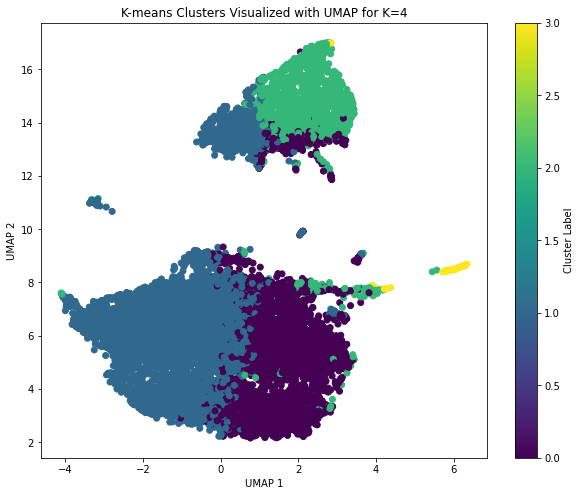

Cluster 0 for K=4 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
6    603
5    571
7    541
4    495
3    468
2    451
1    384
Name: sample_ID, dtype: int64

Cluster 1 for K=4 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
5    853
7    835
6    811
4    775
3    734
2    651
1    632
Name: sample_ID, dtype: int64

Cluster 2 for K=4 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    468
2    389
3    289
4    220
7    109
6     73
5     68
Name: sample_ID, dtype: int64

Cluster 3 for K=4 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    16
7    15
6    13
4    10
2     9
3     9
5     8
Name: sample_ID, dtype: int64



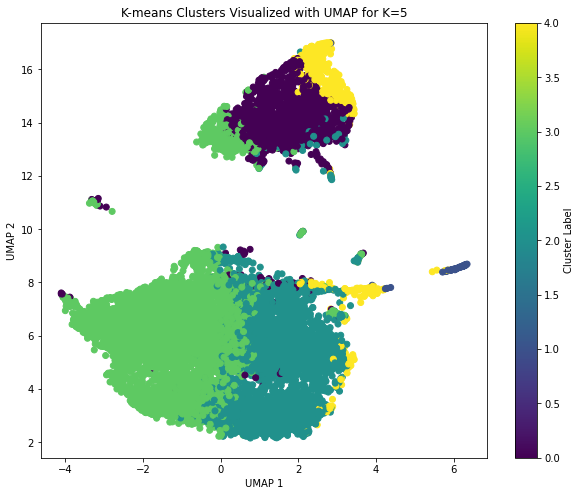

Cluster 0 for K=5 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    541
2    467
3    350
4    247
5     54
7     44
6     24
Name: sample_ID, dtype: int64

Cluster 1 for K=5 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    15
7    14
6    10
4     9
5     8
2     7
3     6
Name: sample_ID, dtype: int64

Cluster 2 for K=5 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
6    605
5    569
7    550
4    456
3    427
2    401
1    334
Name: sample_ID, dtype: int64

Cluster 3 for K=5 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
5    830
7    814
6    791
4    715
3    640
2    524
1    490
Name: sample_ID, dtype: int64

Cluster 4 for K=5 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    120
2 

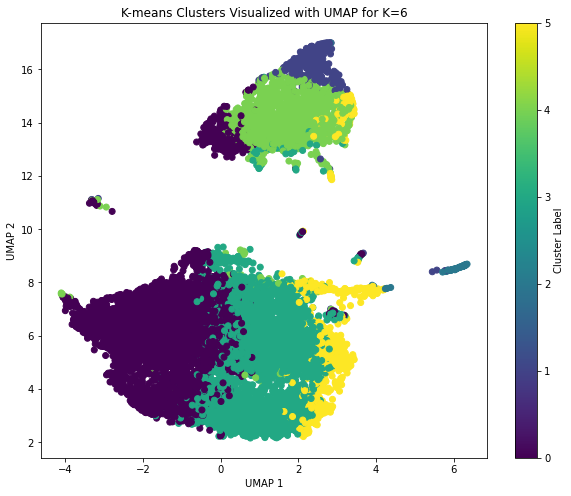

Cluster 0 for K=6 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
7    719
5    690
6    662
4    610
3    541
2    447
1    402
Name: sample_ID, dtype: int64

Cluster 1 for K=6 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    87
2    66
7    64
6    47
3    40
5    31
4    30
Name: sample_ID, dtype: int64

Cluster 2 for K=6 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    15
7    14
6    11
4     9
5     8
2     7
3     6
Name: sample_ID, dtype: int64

Cluster 3 for K=6 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
6    660
5    631
7    574
4    503
3    475
2    410
1    384
Name: sample_ID, dtype: int64

Cluster 4 for K=6 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    526
2    455


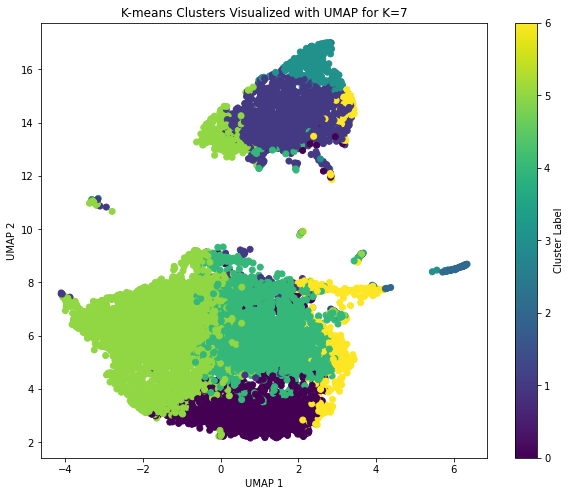

Cluster 0 for K=7 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
2    346
3    332
4    315
1    307
5    168
6     17
7      1
Name: sample_ID, dtype: int64

Cluster 1 for K=7 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    535
2    455
3    354
4    247
5     44
7     24
6     11
Name: sample_ID, dtype: int64

Cluster 2 for K=7 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    15
7    14
6    11
4     9
5     8
2     7
3     6
Name: sample_ID, dtype: int64

Cluster 3 for K=7 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    87
2    66
7    64
6    47
3    39
5    31
4    30
Name: sample_ID, dtype: int64

Cluster 4 for K=7 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
6    721
7    672


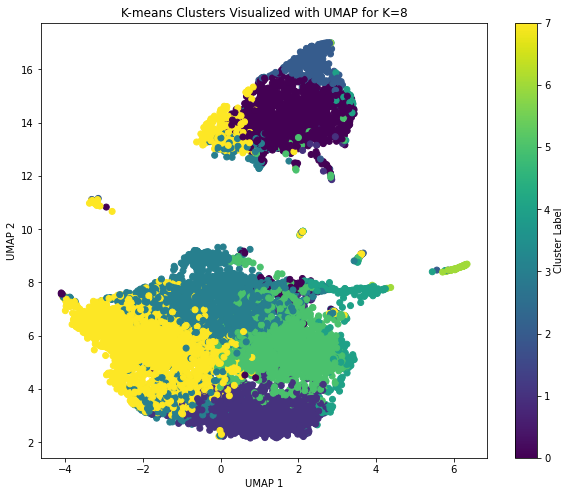

Cluster 0 for K=8 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    503
2    450
3    344
4    253
5     44
7     26
6      8
Name: sample_ID, dtype: int64

Cluster 1 for K=8 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
2    310
3    287
4    287
1    267
5    141
6     13
7      1
Name: sample_ID, dtype: int64

Cluster 2 for K=8 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    80
7    65
2    61
6    48
3    37
5    31
4    29
Name: sample_ID, dtype: int64

Cluster 3 for K=8 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
5    362
7    358
3    335
6    326
4    304
1    280
2    253
Name: sample_ID, dtype: int64

Cluster 4 for K=8 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
7    50
2  

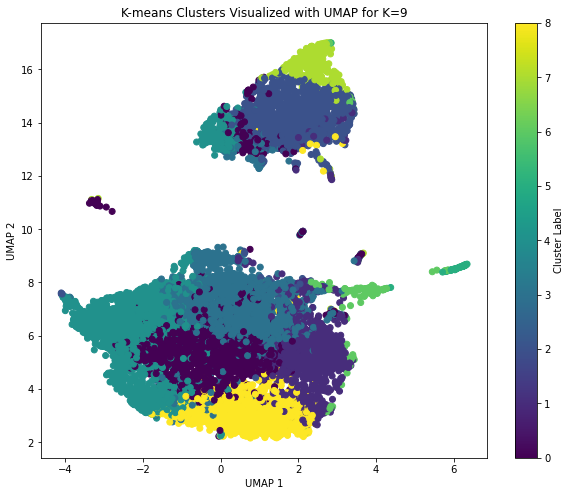

Cluster 0 for K=9 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
6    475
7    386
5    356
4    216
3    153
2    125
1     70
Name: sample_ID, dtype: int64

Cluster 1 for K=9 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
6    324
7    278
5    257
4    134
3     89
2     78
1     63
Name: sample_ID, dtype: int64

Cluster 2 for K=9 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    492
2    427
3    333
4    237
5     34
7     21
6      5
Name: sample_ID, dtype: int64

Cluster 3 for K=9 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
7    380
6    329
5    326
3    247
4    228
1    191
2    171
Name: sample_ID, dtype: int64

Cluster 4 for K=9 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
4   

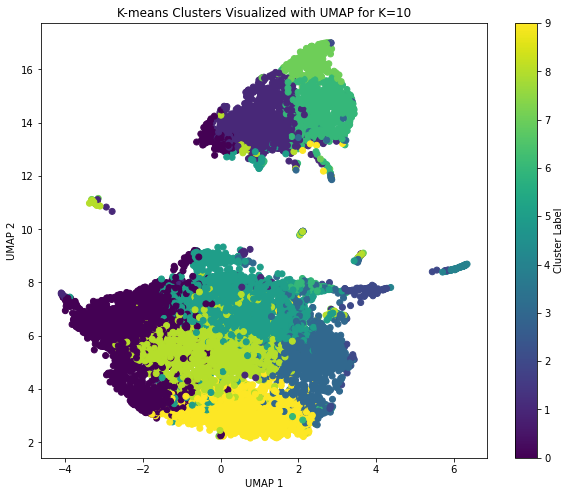

Cluster 0 for K=10 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
5    367
4    356
7    335
3    325
6    291
2    257
1    253
Name: sample_ID, dtype: int64

Cluster 1 for K=10 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    367
2    318
3    240
4    160
5     36
7     21
6      7
Name: sample_ID, dtype: int64

Cluster 2 for K=10 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
7    26
6    22
1    18
4    15
2    13
3    11
5    10
Name: sample_ID, dtype: int64

Cluster 3 for K=10 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
6    291
7    252
5    236
4    117
3     85
2     68
1     51
Name: sample_ID, dtype: int64

Cluster 4 for K=10 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    1

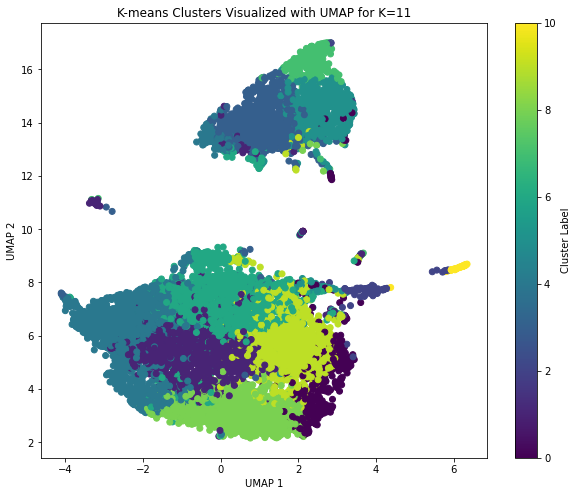

Cluster 0 for K=11 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
4    93
2    88
5    88
3    67
6    64
7    52
1    44
Name: sample_ID, dtype: int64

Cluster 1 for K=11 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
6    448
7    359
5    317
4    195
3    121
2     85
1     41
Name: sample_ID, dtype: int64

Cluster 2 for K=11 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
7    24
6    19
1    16
2    12
4    12
3    10
5     7
Name: sample_ID, dtype: int64

Cluster 3 for K=11 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    357
2    309
3    233
4    157
5     34
7     19
6      6
Name: sample_ID, dtype: int64

Cluster 4 for K=11 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
5    301
4   

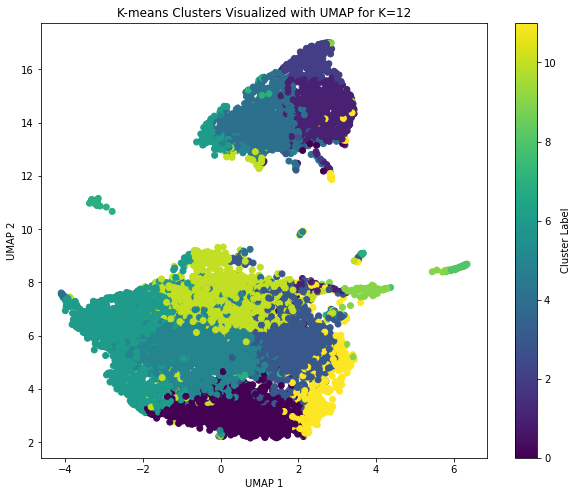

Cluster 0 for K=12 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
2    312
3    295
1    273
4    259
5    129
6     10
7      1
Name: sample_ID, dtype: int64

Cluster 1 for K=12 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    251
2    226
3    177
4    132
5     24
7     12
6     10
Name: sample_ID, dtype: int64

Cluster 2 for K=12 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    69
7    62
2    51
6    43
3    30
4    29
5    29
Name: sample_ID, dtype: int64

Cluster 3 for K=12 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
6    392
7    357
5    280
4    101
3     66
1     49
2     48
Name: sample_ID, dtype: int64

Cluster 4 for K=12 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    3

In [14]:
# Step 1: Extract the data matrix from the AnnData object
X = standard_adata_sub.X  # Ensure it's in a compatible format

# Convert to dense format if necessary
if isinstance(X, np.ndarray) is False:
    X = X.toarray()

# Dimensionality reduction for visualization using UMAP (calculate once)
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Store UMAP coordinates in the AnnData object
standard_adata_sub.obsm['X_umap'] = embedding

# Define a list of K values to loop through
k_values = [4,5,6,7,8,9,10,11,12]

for k in k_values:
    # Run K-means clustering for the current value of K
    kmeans = KMeans(n_clusters=k, random_state=0).fit(X)
    
    # Assign the cluster labels back to the AnnData object
    cluster_label = f'kmeans_clusters_k{k}'
    standard_adata_sub.obs[cluster_label] = kmeans.labels_.astype(str)
    
    # Plotting the clusters for the current value of K using the pre-computed UMAP coordinates
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=kmeans.labels_, cmap='viridis')
    plt.title(f'K-means Clusters Visualized with UMAP for K={k}')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.colorbar(scatter, label='Cluster Label')
    plt.show()

    # Report sample_IDs present in each cluster and their counts
    for i in range(k):
        cluster_sample_ids = standard_adata_sub.obs.loc[standard_adata_sub.obs[cluster_label] == str(i), 'sample_ID']
        print(f'Cluster {i} for K={k} analysis:')
        # Reporting unique sample_IDs
        unique_sample_ids = cluster_sample_ids.unique()
        print(f'Contains unique sample_IDs: {unique_sample_ids}')
        # Reporting counts of cells from each sample_ID in the cluster
        sample_id_counts = cluster_sample_ids.value_counts()
        print(f'Counts of cells from each sample_ID in the cluster:\n{sample_id_counts}\n')


In [17]:
#Save the entire adata file with new PHATE embeddings
adata_save_path = os.path.join(base_dir, 'standard_adata_sub__control_abema_PHATE_kmeans_assigned.h5ad')
standard_adata_sub.write_h5ad(adata_save_path)